# HMC chain initializations — `04_optimize_hmc_chains.py`

Visualize the **K overdispersed per-chain starting layouts** that the multi-chain NUTS sampler launches from. All config (`INIT_SCHEMES`, `NUTS_NUM_CHAINS`, `NUTS_INIT_OVERDISP_SIGMA`, `OPT_DIR_TEMPLATE`, `SEED`, …) and the mountain loader are imported directly from `04_optimize_hmc_chains.py` so this notebook stays in sync if the script changes.

Per-chain start construction matches `nuts_sampling_multichain`:

1. Base layout = Adam-best from the corresponding `OPT_DIR_TEMPLATE` folder if it exists, otherwise the raw `mountain.sample_initial_layout(scheme=...)` so this notebook still runs before any optimization.
2. Add iid Gaussian perturbations of std `NUTS_INIT_OVERDISP_SIGMA` to every coordinate, K=`NUTS_NUM_CHAINS` times.
3. Project each perturbed layout back onto the mountain — NUTS itself runs unconstrained, but projecting shows what the sampler effectively explores.

In [1]:
import os, sys, importlib.util

HERE = os.path.abspath(os.path.join(os.getcwd(), os.pardir))   # notebooks/ -> v6/
if HERE not in sys.path:
    sys.path.insert(0, HERE)

# Load 04_optimize_hmc_chains.py as a module — filename starts with a digit
# so a regular import won't work. Going through importlib gives us every
# constant, helper, and the mountain loader from one source of truth.
_spec = importlib.util.spec_from_file_location(
    "opt_hmc_chains", os.path.join(HERE, "04_optimize_hmc_chains.py"),
)
opt = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(opt)

import numpy as np
import torch
import matplotlib.pyplot as plt

mountain = opt.load_tr_mountain(
    opt.GEOMETRY_PATH, opt.GEOMETRY_GROUP, opt.DET_KEY,
    east_entry=opt.EAST_ENTRY, layer_east_dx=opt.LAYER_EAST_DX, n_planes=opt.N_PLANES,
)
print(f"INIT_SCHEMES             = {opt.INIT_SCHEMES}")
print(f"NUTS_NUM_CHAINS          = {opt.NUTS_NUM_CHAINS}")
print(f"NUTS_PRIOR_SIGMA         = {opt.NUTS_PRIOR_SIGMA} m")
print(f"NUTS_INIT_OVERDISP_SIGMA = {opt.NUTS_INIT_OVERDISP_SIGMA} m")
print(f"SEED                     = {opt.SEED}")
print(f"mountain centroids       : {mountain.centroids_NUE.shape}")

INIT_SCHEMES             = ('grid', 'center')
NUTS_NUM_CHAINS          = 4
NUTS_PRIOR_SIGMA         = 100.0 m
NUTS_INIT_OVERDISP_SIGMA = 1000.0 m
SEED                     = 42
mountain centroids       : (2161, 3)


In [2]:
def get_base_layout(scheme: str):
    """Adam-best if available (realistic NUTS base), else raw scheme init."""
    adam_path = os.path.join(opt.OPT_DIR_TEMPLATE.format(scheme=scheme), "layout_adam.pt")
    if os.path.isfile(adam_path):
        ck = torch.load(adam_path, map_location="cpu")
        print(f"[{scheme}] base = Adam-best layout from {adam_path}")
        return ck["x"].float(), ck["y"].float(), "adam"
    N_np, U_np = mountain.sample_initial_layout(n_units=opt.N_DETECTORS, scheme=scheme)
    N_t = torch.as_tensor(N_np, dtype=torch.float32)
    U_t = torch.as_tensor(U_np, dtype=torch.float32)
    N_t, U_t = mountain.project_to_mountain(N_t, U_t)
    print(f"[{scheme}] base = raw scheme init (no Adam artifact yet)")
    return N_t, U_t, "scheme"


def make_chain_inits(base_x, base_y, K: int, sigma: float, seed: int):
    """K iid Gaussian perturbations around (base_x, base_y), then mountain-project.

    Mirrors the init batch construction in `opt.nuts_sampling_multichain`.
    Returns raw + projected so we can see how far the perturbation drags
    points off the surface."""
    g = torch.Generator().manual_seed(seed)
    D = base_x.numel() + base_y.numel()
    base = torch.cat([base_x, base_y], dim=0)
    perturb = torch.randn(K, D, generator=g) * sigma
    raw = base.unsqueeze(0) + perturb                            # (K, D)
    raw_x = raw[:, :opt.N_DETECTORS]
    raw_y = raw[:, opt.N_DETECTORS:]
    proj_x = torch.empty_like(raw_x)
    proj_y = torch.empty_like(raw_y)
    for k in range(K):
        px, py = mountain.project_to_mountain(raw_x[k], raw_y[k])
        proj_x[k] = px.float()
        proj_y[k] = py.float()
    return raw_x.numpy(), raw_y.numpy(), proj_x.numpy(), proj_y.numpy()


data = {}
for scheme in opt.INIT_SCHEMES:
    bx, by, base_source = get_base_layout(scheme)
    raw_x, raw_y, proj_x, proj_y = make_chain_inits(
        bx, by, K=opt.NUTS_NUM_CHAINS,
        sigma=opt.NUTS_INIT_OVERDISP_SIGMA, seed=opt.SEED,
    )
    data[scheme] = dict(
        base_x=bx.numpy(), base_y=by.numpy(), base_source=base_source,
        raw_x=raw_x, raw_y=raw_y, proj_x=proj_x, proj_y=proj_y,
    )
    print(f"  {scheme}: per-detector drift  "
          f"mean |Δx|={np.mean(np.abs(raw_x - bx.numpy())):.1f} m  "
          f"mean |Δy|={np.mean(np.abs(raw_y - by.numpy())):.1f} m")

[grid] base = raw scheme init (no Adam artifact yet)
  grid: per-detector drift  mean |Δx|=786.2 m  mean |Δy|=808.9 m
[center] base = raw scheme init (no Adam artifact yet)
  center: per-detector drift  mean |Δx|=786.2 m  mean |Δy|=808.9 m


## Combined view — all K chain starts on one axis

One panel per init scheme. Base layout is the larger black markers; each chain's perturbed start is one color. Projected onto the mountain so the picture matches what the sampler effectively explores.

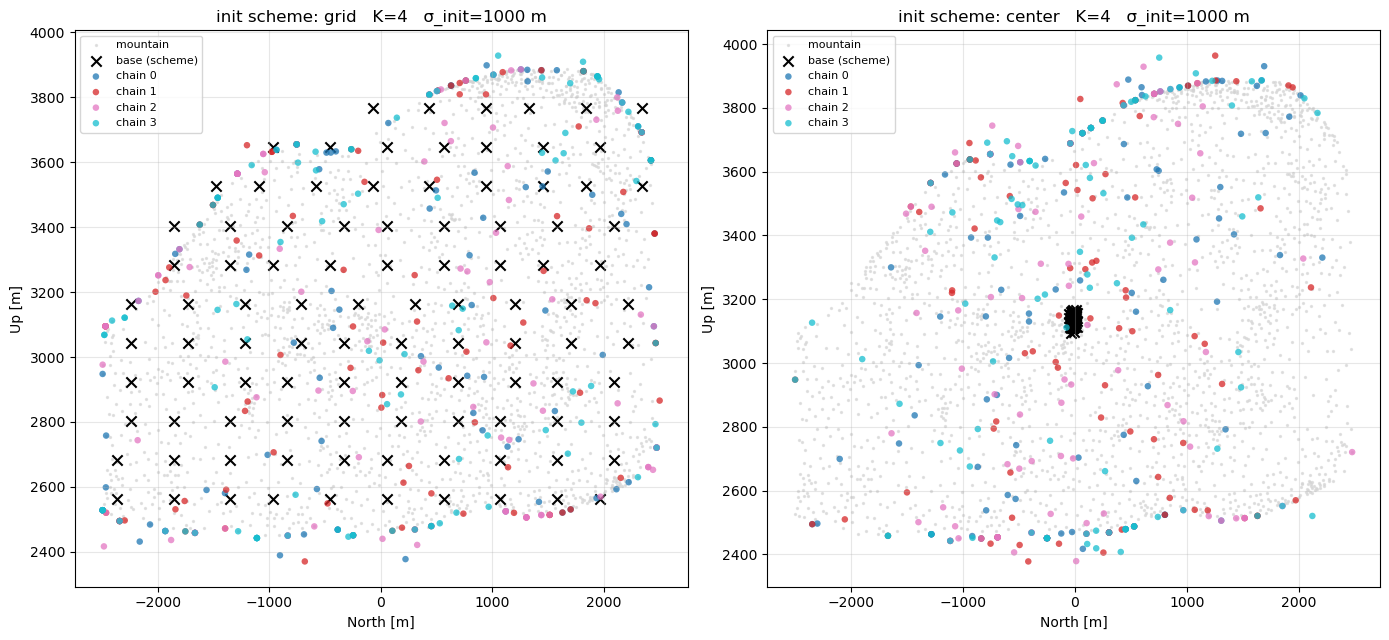

In [3]:
fig, axes = plt.subplots(1, len(opt.INIT_SCHEMES),
                          figsize=(7 * len(opt.INIT_SCHEMES), 6.5))
if len(opt.INIT_SCHEMES) == 1:
    axes = [axes]

chain_colors = plt.cm.tab10(np.linspace(0, 1, opt.NUTS_NUM_CHAINS))

for ax, scheme in zip(axes, opt.INIT_SCHEMES):
    d = data[scheme]
    ax.scatter(mountain.centroids_NUE[:, 0], mountain.centroids_NUE[:, 1],
               s=2, c="lightgray", alpha=0.6, label="mountain")
    ax.scatter(d["base_x"], d["base_y"], s=55, c="black", marker="x",
               linewidths=1.5, label=f"base ({d['base_source']})")
    for k in range(opt.NUTS_NUM_CHAINS):
        ax.scatter(d["proj_x"][k], d["proj_y"][k], s=22,
                   color=chain_colors[k], alpha=0.75, edgecolors="none",
                   label=f"chain {k}")
    ax.set_aspect("equal")
    ax.set_xlabel("North [m]")
    ax.set_ylabel("Up [m]")
    ax.set_title(
        f"init scheme: {scheme}   K={opt.NUTS_NUM_CHAINS}   "
        f"σ_init={opt.NUTS_INIT_OVERDISP_SIGMA:.0f} m"
    )
    ax.legend(loc="best", fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_aspect("auto")

fig.tight_layout()
plt.show()

## Per-chain panels

Same data, one subplot per (scheme, chain). Useful for spotting individual chains whose starts have drifted far off the mountain — they are the most likely sources of poor mixing / high R̂.

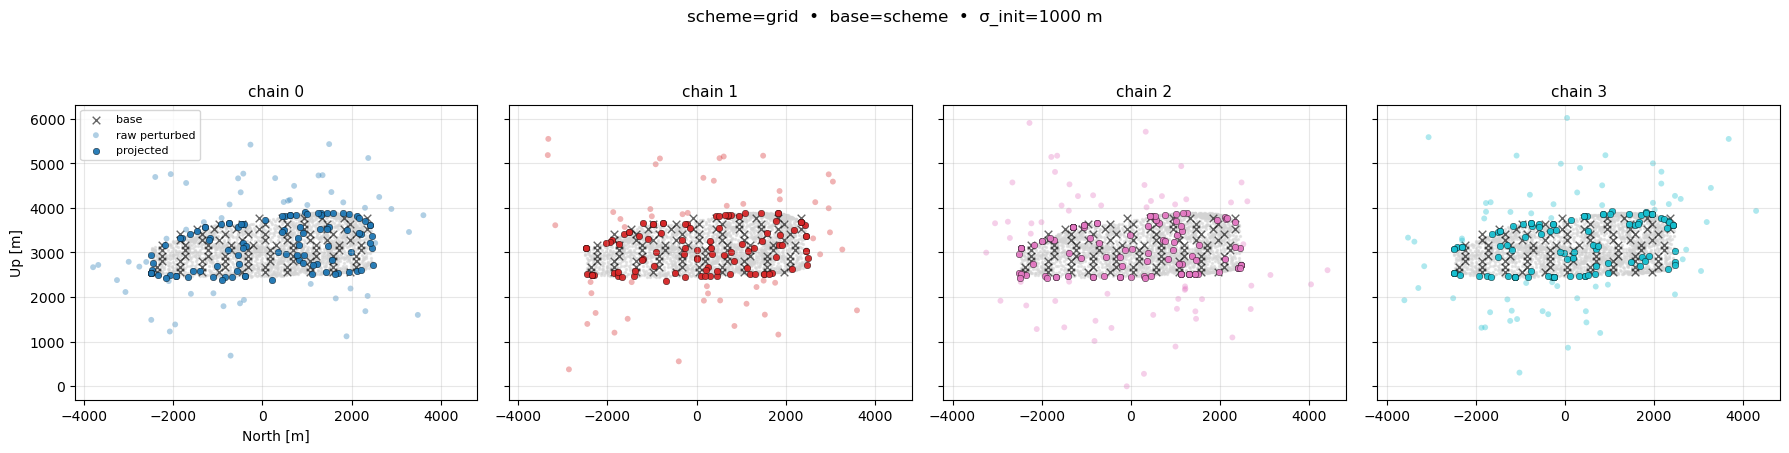

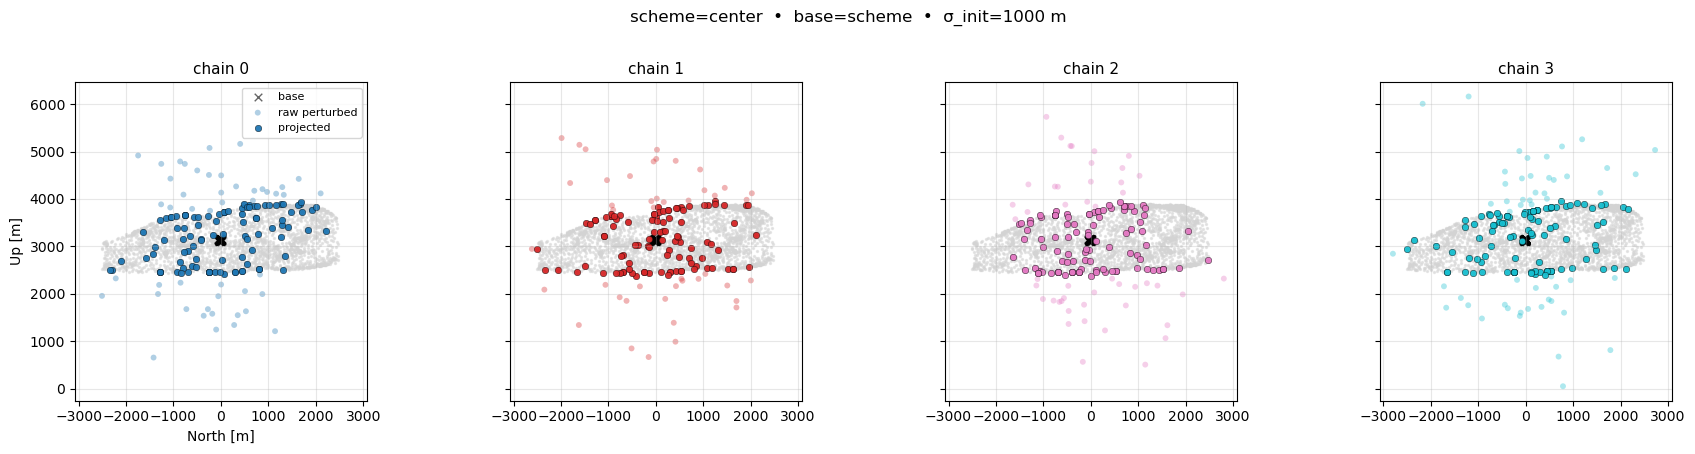

In [4]:
for scheme in opt.INIT_SCHEMES:
    d = data[scheme]
    fig, axes = plt.subplots(1, opt.NUTS_NUM_CHAINS,
                              figsize=(4.5 * opt.NUTS_NUM_CHAINS, 4.5),
                              sharex=True, sharey=True)
    if opt.NUTS_NUM_CHAINS == 1:
        axes = [axes]
    fig.suptitle(
        f"scheme={scheme}  •  base={d['base_source']}  •  "
        f"σ_init={opt.NUTS_INIT_OVERDISP_SIGMA:.0f} m",
        fontsize=12,
    )
    for k, ax in enumerate(axes):
        ax.scatter(mountain.centroids_NUE[:, 0], mountain.centroids_NUE[:, 1],
                   s=2, c="lightgray", alpha=0.5)
        ax.scatter(d["base_x"], d["base_y"], s=30, c="black", marker="x",
                   linewidths=1.0, alpha=0.6, label="base")
        ax.scatter(d["raw_x"][k], d["raw_y"][k], s=18,
                   color=chain_colors[k], alpha=0.35, edgecolors="none",
                   label="raw perturbed")
        ax.scatter(d["proj_x"][k], d["proj_y"][k], s=22,
                   color=chain_colors[k], alpha=0.95,
                   edgecolors="black", linewidths=0.3,
                   label="projected")
        ax.set_aspect("equal")
        ax.set_title(f"chain {k}", fontsize=11)
        ax.grid(alpha=0.3)
        if k == 0:
            ax.set_xlabel("North [m]"); ax.set_ylabel("Up [m]")
            ax.legend(loc="best", fontsize=8)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()

## Per-detector perturbation distribution

Sanity check that the Gaussian perturbation actually has the configured σ and is iid across detectors and chains. Should look like a centered Normal with std ≈ `NUTS_INIT_OVERDISP_SIGMA`.

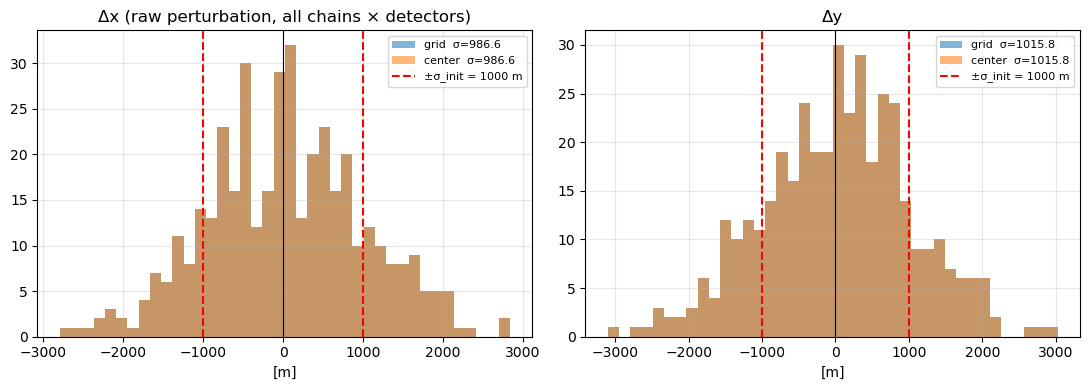

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for scheme in opt.INIT_SCHEMES:
    d = data[scheme]
    dx = (d["raw_x"] - d["base_x"][None, :]).ravel()
    dy = (d["raw_y"] - d["base_y"][None, :]).ravel()
    axes[0].hist(dx, bins=40, alpha=0.55, label=f"{scheme}  σ={dx.std():.1f}")
    axes[1].hist(dy, bins=40, alpha=0.55, label=f"{scheme}  σ={dy.std():.1f}")
axes[0].set_title("Δx (raw perturbation, all chains × detectors)")
axes[1].set_title("Δy")
for ax in axes:
    ax.axvline(0, color="black", linewidth=0.8)
    ax.axvline( opt.NUTS_INIT_OVERDISP_SIGMA, color="red", linestyle="--",
               label=f"±σ_init = {opt.NUTS_INIT_OVERDISP_SIGMA:.0f} m")
    ax.axvline(-opt.NUTS_INIT_OVERDISP_SIGMA, color="red", linestyle="--")
    ax.set_xlabel("[m]")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()